# Building Your First AI Agent with LangChain: From Chatbot to Agent

In this tutorial, we'll explore the evolution from simple chatbots to powerful AI agents by building a pet gift finder. You'll understand the key differences and learn when to use each approach.

## Chatbots vs AI Agents: What's the Difference?

**Chatbots** are conversational interfaces that respond to user input based on their training data. They're great for:
- Answering questions from existing knowledge
- Having conversations
- Providing explanations and advice

**AI Agents** go beyond conversation - they can take actions in the real world using tools. They can:
- Search the web for current information
- Make API calls to external services
- Perform calculations and data analysis
- Execute code and interact with databases

## What You'll Learn
- Start with a simple model (chatbot approach)
- Identify limitations of knowledge-only responses
- Build custom tools for real-world capabilities
- Create a full AI agent with LangChain
- Add multimodal capabilities (text + images)
- Deploy to LangSmith for interactive use

## Prerequisites
- Basic Python knowledge
- OpenAI API key
- Tavily API key (for web search)
- LangSmith API key (optional, for deployment)

Let's start simple and build up!

## Step 1: Environment Setup

First, we'll load our environment variables and optionally enable LangSmith tracing.

In [1]:
from dotenv import load_dotenv
import os

load_dotenv()

# Optional: Enable LangSmith tracing for debugging and monitoring
# Uncomment these lines if you have LangSmith set up
# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "ai-agents-pet-gift-finder"

print("Environment loaded! LangSmith tracing available if configured.")

Environment loaded! LangSmith tracing available if configured.


## Step 2: Starting Simple - The Chatbot Approach

Let's begin with a basic language model to understand what chatbots can and cannot do.

In [2]:
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage, SystemMessage

# Initialize a basic chat model
model = init_chat_model(model="gpt-5-nano")

# Create a system message to define the chatbot's role
system_message = SystemMessage(content="""
You are a helpful pet gift advisor. Help users find Christmas gifts for their pets 
based on your knowledge of pet products and care. Provide specific product suggestions 
when possible.
""")

print("Basic Pet Gift Chatbot initialized!")

Basic Pet Gift Chatbot initialized!


### Testing the Basic Chatbot

In [3]:
# Test the basic chatbot
user_question = HumanMessage(content="I have a playful orange tabby cat. What Christmas gifts would be perfect for him?")

response = model.invoke([system_message, user_question])
print("Chatbot Response:")
print(response.content)

Chatbot Response:
That sounds like a fun holiday plan! For a playful orange tabby, look for gifts that spark chasing, pouncing, climbing, and mental enrichment. Here are mix-and-match ideas with specific product suggestions you can grab online or in stores.

Top gift ideas (with quick why)

- Da Bird Feather Teaser Wand Toy (GoCat/Da Bird)
  - Why: classic chase/fetch toy that taps into a cat’s hunter instincts. Feathers and a light rod make it highly engaging during play sessions.
  - Where: Amazon, Chewy, most pet retailers
  - Tip: Supervised play is best; replace feathers when worn.

- KONG Kickeroo Plush Cat Toy with Catnip
  - Why: soft body for batting and wrestling, with catnip to entice and prolong play.
  - Why: great for solo play or you to play tug/pounce games.
  - Where: Chewy, Amazon, pet stores

- Cat Dancer 101 Cat Toy
  - Why: simple, durable wand toy with a foiled/wand ribbon attachment. Easy to use for quick, energetic sessions.
  - Where: Amazon, Chewy, pet stores


### The Limitations Become Clear

Let's ask for something that requires current information:

In [4]:
# Ask for current pricing and availability
current_info_question = HumanMessage(content="""
What are the current prices for interactive cat toys on Amazon? 
Which ones are in stock right now and have good reviews?
""")

response = model.invoke([system_message, current_info_question])
print("Chatbot Response to Current Info Request:")
print(response.content)
print("\n" + "="*50)
print("LIMITATION: The chatbot can't access real-time information!")
print("It can only work with its training data, which has a cutoff date.")

Chatbot Response to Current Info Request:
I don’t have real-time access to Amazon right now, so I can’t pull current prices, stock status, or live review scores. But I can help you shop efficiently and point you to strong, well-loved options. If you want, I can guide you step-by-step to pull live results or tailor picks to your budget and cats’ personalities.

Quick plan to find current prices, stock, and reviews on Amazon
- Search terms: try “interactive cat toy,” “automatic laser toy,” or “robotic cat toy.”
- Use filters: In Stock, Prime eligible, and Cat Toys (Pet Supplies).
- Sort options: by Avg. Customer Review (high to low) or by “Newest.”
- Review checks: aim for 4.5+ star ratings with 500+ reviews; read a few recent comments about durability, battery life, and how long it holds a cat’s attention.
- Safety notes: check age/weight guidance, avoid small parts for kittens, and verify that the toy is battery-operated or USB-rechargeable as you prefer.
- Quick sanity check: ensure t

## Step 3: Why We Need Agents

The chatbot approach has several limitations:

1. **No real-time information** - Can't check current prices, availability, or reviews
2. **No verification** - Can't confirm if products actually exist
3. **Static knowledge** - Information becomes outdated
4. **No actions** - Can't actually help you buy anything

**This is where AI agents shine!** Agents can use tools to:
- Search the web for current information
- Check real prices and availability
- Find the latest products and reviews
- Even help with purchasing (with the right integrations)

Let's build an agent that can actually help!

## Step 4: Creating Tools - The Agent's Superpowers

Now we'll give our AI the ability to take actions in the real world. Tools are Python functions that agents can call to perform specific tasks.

In [5]:
from langchain.tools import tool
from typing import Dict, Any
from tavily import TavilyClient

# Initialize the Tavily client for web searching
tavily_client = TavilyClient()

@tool
def web_search(query: str) -> Dict[str, Any]:
    """Search the web for current information about pet gifts, products, and shopping"""
    return tavily_client.search(query)

@tool
def pet_gift_search(pet_type: str, pet_characteristics: str, budget: str = "moderate", location: str = "US") -> Dict[str, Any]:
    """Search for specific pet gifts based on type, characteristics, budget, and location"""
    search_query = f"Christmas gifts for {pet_type} {pet_characteristics} {budget} budget 2024 where to buy {location}"
    return tavily_client.search(search_query)

@tool
def local_store_search(product_name: str, location: str) -> Dict[str, Any]:
    """Find local pet stores and retailers in a specific location that might carry a product"""
    search_query = f"pet stores near {location} {product_name} in stock local retailers"
    return tavily_client.search(search_query)

print("Location-aware tools created! Our agent can now find gifts globally and locate nearby stores.")

Location-aware tools created! Our agent can now find gifts globally and locate nearby stores.


### Testing Our Tools

Let's test one of our tools directly to see how it works:

In [20]:
# Test our tool directly
test_result = web_search.invoke({"query": "best interactive cat toys 2025 Amazon"})
print("Direct tool result (first result):")
print(f"Title: {test_result['results'][0]['title']}")
print(f"URL: {test_result['results'][0]['url']}")
print(f"Content: {test_result['results'][0]['content'][:200]}...")
print("\nThis is real, current information from the web!")

Direct tool result (first result):
Title: Interactive Cat Toy
URL: https://www.amazon.com/interactive-cat-toy/s?k=interactive+cat+toy
Content: Potaroma Moving Ball Cat Toys with Feather Tail, Rechargeable 2025 New Interactive Toy for Indoor Cats Exercise, Smart Interactive Kitten Rolling Ball, Orange....

This is real, current information from the web!


In [21]:
test_result

{'query': 'best interactive cat toys 2025 Amazon',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.amazon.com/interactive-cat-toy/s?k=interactive+cat+toy',
   'title': 'Interactive Cat Toy',
   'content': 'Potaroma Moving Ball Cat Toys with Feather Tail, Rechargeable 2025 New Interactive Toy for Indoor Cats Exercise, Smart Interactive Kitten Rolling Ball, Orange.',
   'score': 0.8898454,
   'raw_content': None},
  {'url': 'https://www.amazon.com/interactive-cat-toys/s?k=interactive+cat+toys',
   'title': 'Interactive Cat Toys',
   'content': 'k=interactive+cat+toys&rh=p_76%3A2661625011&dc&qid=1767008946&rnid=2661623011&ref=sr_nr_p_76_1&ds=v1%3AfdZu%2Byr29KpFXoEFkwQrpKckK3AxVCC3TDdBaGk6VB8). k=interactive+cat+toys&rh=p_90%3A8308921011&dc&qid=1767008946&rnid=8308919011&ref=sr_nr_p_90_1&ds=v1%3Ar%2FUPvPdrTApewe5Ty4rC2I2pbPBK4LVsUKfqobVB2aI). k=interactive+cat+toys&rh=p_n_g-101014830772111%3A117913556011&dc&qid=1767008946&rnid=117913517011&re

## Step 5: Designing the Agent's System Prompt

The system prompt is crucial for agents - it needs to explain not just the role, but also how to use tools effectively.

In [7]:
system_prompt = """
You are a helpful pet gift advisor with access to real-time web search capabilities.

Your role:
- Help pet owners find appropriate Christmas gifts based on their pet's characteristics
- Use your web search tools to find current products, prices, and availability
- Consider pet safety, size, age, and personality when making recommendations
- Provide specific product suggestions with purchasing information
- Offer options across different budget ranges
- Help users find local stores and retailers in their area

When to use tools:
- Use web_search for general queries about pet products, reviews, or shopping
- Use pet_gift_search when you have specific pet characteristics, budget, and location info
- Use local_store_search to find nearby pet stores that might carry specific products
- Always ask for the user's location if they want local shopping options
- Always search for current information rather than relying on outdated knowledge

Location examples:
- For US users: Search Amazon, Petco, PetSmart, Chewy
- For Philippines users: Search Shopee, Lazada, local pet stores in Manila/Cebu/Davao
- For other countries: Adapt to local e-commerce and pet store chains

When analyzing pets from photos:
- Identify breed characteristics that might influence gift choices
- Estimate size and age if possible
- Note any visible personality traits or energy levels

Always prioritize pet safety and provide real, purchasable products with current pricing and local availability.
"""

print("System prompt created with location-aware instructions!")

System prompt created with location-aware instructions!


## Step 6: Creating the AI Agent

Now we'll combine everything into a powerful AI agent:

In [22]:
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver

# Create our AI agent with tools
agent = create_agent(
    model="gpt-5-nano",
    tools=[web_search, pet_gift_search, local_store_search],
    system_prompt=system_prompt,
    checkpointer=InMemorySaver()  # Enables conversation memory
)

print("AI Agent created! It now has location-aware search capabilities.")

AI Agent created! It now has location-aware search capabilities.


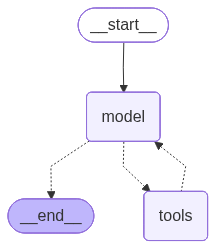

In [23]:
agent

## Step 7: Adding Streaming Responses

Before we test our agent, let's add streaming capabilities for a better user experience. Streaming shows responses as they're generated, making the interaction feel more natural and responsive.

In [9]:
def stream_agent_response(message, config, show_thinking=True):
    """Stream the agent's response for better user experience"""
    if show_thinking:
        print("🤖 Agent is thinking and searching...\n")
    
    # Stream the response using proper streaming format
    for token, metadata in agent.stream({"messages": [HumanMessage(content=message)]}, config, stream_mode="messages"):
        # token is a message chunk with token content
        # metadata contains which node produced the token
        if token.content:  # Check if there's actual content
            print(token.content, end="", flush=True)  # Print token
    
    print("\n\n✅ Response complete!")

print("Streaming function created! Now responses will appear in real-time.")

Streaming function created! Now responses will appear in real-time.


## Step 8: Testing the Agent with Streaming

Let's test our agent with streaming responses for a better user experience:

In [10]:
from langchain.messages import HumanMessage

# Configuration for conversation memory
config = {"configurable": {"thread_id": "pet_gift_session_1"}}

# Test with streaming - same question we asked the basic chatbot
print("🐱 Question: I have a playful orange tabby cat who loves to chase things and knock items off tables. What Christmas gifts would be perfect for him?\n")

stream_agent_response(
    "I have a playful orange tabby cat who loves to chase things and knock items off tables. What Christmas gifts would be perfect for him?",
    config
)

🐱 Question: I have a playful orange tabby cat who loves to chase things and knock items off tables. What Christmas gifts would be perfect for him?

🤖 Agent is thinking and searching...

{"query": "Catit Senses 2.0 Play Circuit price", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.bluebarn.shop/product/catit-senses-2-0-play-circuit/?srsltid=AfmBOopTw28ypoC5Ocq-W5nTXZyeXhsnDFcYAnT1wP2ANJdwbT3wYmYH", "title": "CATIT Senses 2.0 Play Circuit Interactive Cat Toy", "content": "$19.99 Original price was: $19.99. $14.99 Current price is: $14.99. ... The new Catit Senses 2.0 Play Circuit is the ultimate hunting toy for your cat.", "score": 0.9999962, "raw_content": null}, {"url": "https://shop.vivapets.com/us/catit-senses-2-0-play-circuit", "title": "Catit Senses 2.0 Play Circuit - Available at Vivapets Now", "content": "... 27cm (LxWxH). Weight: 750 g. Related. Catit Senses 2.0 Super Circuit · Price $53.62", "score": 0.9999951, "raw_content": null},

### Comparing: Non-Streaming vs Streaming

Let's also show the traditional non-streaming approach for comparison:

In [11]:
# Traditional non-streaming approach (for comparison)
print("📝 Traditional Non-Streaming Response:\n")

response = agent.invoke(
    {"messages": [HumanMessage(content="What are some budget-friendly cat toys under $20?")]},
    config
)

print("AI Agent Response (traditional):")
print(response['messages'][-1].content)
print("\n" + "="*50)
print("Notice: Traditional responses appear all at once after processing is complete.")
print("Streaming responses appear progressively, providing better user experience!")

📝 Traditional Non-Streaming Response:

AI Agent Response (traditional):
Nice! Here are budget-friendly cat toys under $20 that are great for a playful, chase-happy cat. Each option has current pricing and a link so you can check out quickly.

Under $10
- KONG Kickeroo Kitten Toy (Small) — around $6.49
  - Why: simple, soft plush that’s perfect for batting and pouncing.
  - Buy: Chewy listing shows $6.49.
  - Link: https://www.chewy.com/kong-kickeroo-cuddler-cat-toy-color/dp/170084 (Kickeroo Kitten Toy often shown around this price)

- KONG Kickeroo Cuddler Cat Toy — around $8.99
  - Why: plush teaser that’s easy to grab and kick.
  - Buy: Chewy shows $8.99.
  - Link: https://www.chewy.com/kong-kickeroo-cuddler-cat-toy-color/dp/170084

- KONG Christmas Holiday Kickeroo Cactus Plush Cat Toy (with catnip) — around $8.62
  - Why: seasonal, soft, great for tossing and grabbing.
  - Buy: Chewy shows ~$8.62.
  - Link: https://www.chewy.com/kong-holiday-kickeroo-cactus-plush/dp/1761286

Under 

### Testing Current Information with Streaming - The Agent's Superpower

In [12]:
from langchain.messages import HumanMessage

# Configuration for conversation memory
config = {"configurable": {"thread_id": "pet_gift_session_1"}}

# Ask the same question we asked the basic chatbot
response = agent.invoke(
    {"messages": [HumanMessage(content="I have a playful orange tabby cat who loves to chase things and knock items off tables. What Christmas gifts would be perfect for him?")]},
    config
)

print("AI Agent Response (with real-time web search):")
print(response['messages'][-1].content)

AI Agent Response (with real-time web search):
Great picks for a playful orange tabby who likes to chase and knock things over—plus some ideas that fit Christmas gifting nicely. I’ve focused on toys that encourage chasing, pouncing, and problem-solving, with current price ranges and where to buy.

Top budget-friendly chase toys (often under $20)
- Da Bird Original Feather Teaser Wand (Go Cat Da Bird)
  - Why: classic feather teaser that sparks fast chases and big play sessions.
  - Price: around $9.99 (varies by retailer)
  - Buy: Natural Pet Center price example: https://shop.naturalpetcenter-nd.com/products/023c72a6-e9c8-11ea-e2fd-9c65411f2c2a

- KONG Kickeroo Kitten Toy (small) or KONG Kickeroo Cuddler
  - Why: soft, enticing plush for batting and pouncing; great for table-edge play.
  - Price: Kitten Toy ~ $6.49; Cuddler ~ $8.99
  - Buy: 
    - Kitten Toy: https://www.chewy.com/kong-kickeroo-kitten-toy-color-varies/dp/180796
    - Cuddler: https://www.chewy.com/kong-kickeroo-cuddle

### Testing Current Information - The Agent's Superpower

In [13]:
# Test current information with streaming - the question that stumped the chatbot
print("💰 Question: What are the current prices for interactive cat toys on Amazon? Which ones are in stock right now and have good reviews?\n")

stream_agent_response(
    "What are the current prices for interactive cat toys on Amazon? Which ones are in stock right now and have good reviews?",
    config
)

print("\n" + "="*50)
print("🎉 SUCCESS: The agent can access real-time information with streaming!")
print("You can see the agent thinking, using tools, and building the response in real-time.")

💰 Question: What are the current prices for interactive cat toys on Amazon? Which ones are in stock right now and have good reviews?

🤖 Agent is thinking and searching...

Error invoking tool 'web_search' with kwargs {'parameters': {'query': 'Nina Ottosson Puzzle Cat Toy Amazon price stock'}} with error:
 query: Field required
 Please fix the error and try again.{"query": "Petstages Tower of Tracks Amazon price stock", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.amazon.ca/Petstages-Tower-Tracks-Pet-Toys/dp/B00DT2WL26", "title": "Petstages Tower of Tracks Interactive 3-Tier Cat Toy - Amazon.ca", "content": "The Petstages Tower of Tracks ball track toy for cats has three levels and three colorful balls for three times the fun!", "score": 0.9998776, "raw_content": null}, {"url": "https://www.amazon.com/petstages-cat-toy/s?k=petstages+cat+toy", "title": "Petstages Cat Toy - Amazon.com", "content": "Tower of Tracks Cat Toy – 3-Level Track Towe

## Step 9: Location-Aware Shopping with Streaming

Let's test the location-aware capabilities with streaming responses for different regions:

In [14]:
# Example for Philippines users with streaming
print("🇵🇭 Question: I'm in Manila, Philippines and have a small Shih Tzu. What Christmas gifts can I find locally or on Filipino e-commerce sites like Shopee or Lazada? Budget is around 1000-2000 PHP.\n")

stream_agent_response(
    "I'm in Manila, Philippines and have a small Shih Tzu. What Christmas gifts can I find locally or on Filipino e-commerce sites like Shopee or Lazada? Budget is around 1000-2000 PHP.",
    config
)

🇵🇭 Question: I'm in Manila, Philippines and have a small Shih Tzu. What Christmas gifts can I find locally or on Filipino e-commerce sites like Shopee or Lazada? Budget is around 1000-2000 PHP.

🤖 Agent is thinking and searching...

{"query": "snuffle mat Philippines price Lazada Shopee", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.lazada.com.ph/tag/pet-snuffle-mats/", "title": "Shop Pet Snuffle Mats Cheap – Fast & Easy | Lazada Philippines", "content": "Pet Snuffle Mat for Dogs Nosework Feeding Mat Slow Feeder for Training and Stress Relief Encourages Natural Foraging Skills. ₱209.61.", "score": 0.8939131, "raw_content": null}, {"url": "https://www.lazada.com.ph/tag/snuffle-mat/", "title": "Get Snuffle Mat at the Best Prices Online - Lazada Philippines", "content": "Dog Snuffle Mat for Dogs Reduces Boredom & Anxiety Slow Eating & Smell Training Dog Brain Stimulating Toys Small Dog Bed. ₱230.16.", "score": 0.8925721, "raw_content": null},

In [15]:
# Example for finding local stores with streaming
print("🏪 Question: I found a great interactive puzzle feeder online, but I'd prefer to buy it locally. I'm in Austin, Texas. Can you help me find pet stores nearby that might carry puzzle feeders?\n")

stream_agent_response(
    "I found a great interactive puzzle feeder online, but I'd prefer to buy it locally. I'm in Austin, Texas. Can you help me find pet stores nearby that might carry puzzle feeders?",
    config
)

🏪 Question: I found a great interactive puzzle feeder online, but I'd prefer to buy it locally. I'm in Austin, Texas. Can you help me find pet stores nearby that might carry puzzle feeders?

🤖 Agent is thinking and searching...

{"query": "pet stores near Austin, TX interactive puzzle feeder in stock local retailers", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://locations.hollywoodfeed.com/texas/austin/4604-burnet-rd/", "title": "Hollywood Feed at 4604 Burnet Rd | Pet Store in Austin", "content": "# Hollywood Feed on Burnet Rd Makes Shopping for Pet Supplies in Austin Easy The expert pet people at Hollywood Feed on Burnet Rd can help you choose the best food, toys, treats, and other necessities for your cat or dog. Shop with confidence at Hollywood Feed, knowing you're getting the best value on your pet's essential supplies. Save big on dog and cat food and supplies with the Hollywood Feed Frequent Feeder program! ## **Do Hollywood Feed locati

## Step 10: Advanced Streaming Example

Let's test streaming with a more complex query that will require multiple tool calls:

In [16]:
# Test streaming with a complex query that requires multiple searches
print("🐕 Complex Question: I have a senior dog (12 years old) with arthritis. What Christmas gifts would help with his comfort and mobility? Please include current prices and where to buy them.\n")

stream_agent_response(
    "I have a senior dog (12 years old) with arthritis. What Christmas gifts would help with his comfort and mobility? Please include current prices and where to buy them.",
    config
)

🐕 Complex Question: I have a senior dog (12 years old) with arthritis. What Christmas gifts would help with his comfort and mobility? Please include current prices and where to buy them.

🤖 Agent is thinking and searching...

{"query": "Cosequin DS dog chews price Chewy", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.chewy.com/nutramax-cosequin-hip-joint/dp/36598", "title": "Nutramax Cosequin Maximum Strength (DS) Plus MSM Soft Chews ...", "content": "$75.94 Chewy Price · 75 · 94. ($0.31/ea). Rated 4.6 out of 5 stars ; $49.98 Chewy Price · 49 · 98. ($0.20/ea). Rated 4.6 out of 5 stars ; $59.99 Chewy Price · 59 · 99.", "score": 0.8825193, "raw_content": null}, {"url": "https://www.petmd.com/general-health/cosequin-vs-dasuquin", "title": "Cosequin vs. Dasuquin: What's The Difference? - PetMD", "content": "... Soft Chews for Dogs, 120 count. Rated 4.6 out of 5 stars. 6.6KReviews. $37.97Chewy Price. Shop on Chewy. For senior pups, Cosequin offe

## Step 11: Adding Multimodal Capabilities

Let's add image analysis so users can upload photos of their pets:

In [17]:
from ipywidgets import FileUpload
from IPython.display import display
import base64

uploader = FileUpload(
    accept='.png,.jpg,.jpeg', 
    multiple=False,
    description='Upload Pet Photo'
)
display(uploader)

FileUpload(value=(), accept='.png,.jpg,.jpeg', description='Upload Pet Photo')

In [18]:
def process_uploaded_image():
    """Convert uploaded image to base64 format for the AI model"""
    if not uploader.value:
        return None, None
    
    # Get the uploaded file
    uploaded_file = uploader.value[0]
    
    # Convert memoryview to bytes
    content_mv = uploaded_file["content"]
    img_bytes = bytes(content_mv)
    
    # Base64 encode for the model
    img_b64 = base64.b64encode(img_bytes).decode("utf-8")
    
    return img_b64, uploaded_file["type"]

# Process the image
img_b64, file_type = process_uploaded_image()

if img_b64:
    print("Image processed successfully and ready for analysis!")
else:
    print("Please upload an image first.")

Please upload an image first.


In [19]:
if img_b64:
    # Create a multimodal message with both text and image
    multimodal_message = HumanMessage(content=[
        {
            "type": "text", 
            "text": "Here's a photo of my pet! Please analyze their appearance, size, breed characteristics, and any personality traits you can observe, then recommend Christmas gifts that would be perfect for them. Include specific products and where to buy them."
        },
        {
            "type": "image", 
            "base64": img_b64, 
            "mime_type": file_type
        }
    ])
    
    # Send to our agent
    response = agent.invoke(
        {"messages": [multimodal_message]},
        config
    )
    
    print(response['messages'][-1].content)
else:
    print("Please upload a pet photo first!")

Please upload a pet photo first!


## Step 12: Monitoring with LangSmith (Optional)

LangSmith provides powerful tracing and debugging capabilities for your agents. If you have LangSmith set up, you can monitor:

- **Tool usage**: See which tools your agent calls and why
- **Performance metrics**: Track response times and token usage
- **Debugging**: Inspect the full reasoning chain when things go wrong
- **User feedback**: Collect ratings and improve your agent over time

To enable LangSmith tracing, uncomment the lines in Step 1 and set your LangSmith API key in your `.env` file:

```
LANGCHAIN_API_KEY=your_langsmith_api_key_here
```

Once enabled, you can view traces at [smith.langchain.com](https://smith.langchain.com)

## Key Learnings: Chatbots vs Agents + Streaming Benefits

Through this tutorial, we've seen the evolution from simple chatbots to powerful AI agents with streaming capabilities:

### Chatbots (Step 2)
- ✅ Good for: Conversations, explanations, advice based on training data
- ❌ Limited by: Static knowledge, no real-time information, can't take actions

### AI Agents (Steps 4-13)
- ✅ Can: Search the web, find current prices, locate nearby stores, process images
- ✅ Provide: Real-time information, location-aware recommendations, actionable results
- ✅ Scale: Add new tools easily, monitor performance, stream responses

### Streaming Benefits (Steps 7-10)
- ✅ **Better UX**: Users see responses as they're generated, not all at once
- ✅ **Transparency**: Shows when tools are being used and what the agent is thinking
- ✅ **Engagement**: Keeps users engaged during longer processing times
- ✅ **Real-time feedback**: Users can see the agent working through complex queries

### When to Use Each
- **Use chatbots** for: FAQ systems, educational content, creative writing
- **Use agents** for: Shopping assistance, research tasks, data analysis, real-world actions
- **Use streaming** for: Any agent interaction where response time > 2-3 seconds

The key insight: **Streaming Agents = Chatbots + Tools + Real-world capabilities + Better UX!**

## Step 13: Deploying to LangSmith

To deploy this agent to LangSmith for interactive use:

1. Make sure your `.env` file has all required API keys
2. Use the provided `langgraph_pet_gift.json` configuration file
3. Deploy with: `langgraph deploy --config langgraph_pet_gift.json`

Your agent will then be available through LangSmith's web interface for interactive chat!